# 02 — Sonification: MIDI and WAV from β2AR Dynamics

This notebook converts the per-frame feature time-series produced by
notebook 01 into musical sequences and audio files, organised around
**two explicit pairwise comparisons**:

| Pair        | State A   | State B               | Scientific claim                                                |
|-------------|-----------|-----------------------|------------------------------------------------------------------|
| activation  | inactive  | active                | Do activation-related MD differences produce audible differences?|
| ligand      | active    | active_ligand_bound   | Does agonist binding produce an audible difference within the active ensemble? |

For each pair, both states are rendered with **three instruments**
(piano, violin, flute) using **identical feature mapping, identical
normalisation, identical tempo**. Two complementary outputs are produced
per (pair × instrument):

1. **Individual state WAV files** — for manual A/B listening: open `inactive_piano.wav` and `active_piano.wav` side-by-side.
2. **Pairwise concatenation WAV** — one file with state A, a short silence, then state B; the fastest way to hear the contrast.

### Mapping (same for all pairs and all instruments)

| MD feature             | Musical parameter   |
|------------------------|---------------------|
| `TM3_TM6_distance_A`   | Pitch (quantised to C-major pentatonic) |
| `NPxxY_RMSD_A`         | Note duration       |
| `RMSD_Ca_A`            | Velocity (loudness) |
| `DRY_ionic_lock_A`     | Sustained harmony pad intensity |
| `Ligand_contact_count` | Snare percussion accents (only when ligand present) |


## 1. Mount Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install dependencies


In [ ]:
!pip -q install pretty_midi==0.2.10 pandas numpy matplotlib soundfile scipy
!apt-get -qq update
!apt-get -qq install -y fluidsynth fluid-soundfont-gm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 33.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.3 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to unpack .../02-libevdev2_1.12.1+dfsg-1_amd6

## 3. Imports and paths


In [ ]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
from scipy.io import wavfile

PROJECT_DIR = Path('/content/drive/MyDrive/GPCR_Sonification')
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
AUDIO_DIR = PROJECT_DIR / 'outputs' / 'audio'
FIG_DIR = PROJECT_DIR / 'outputs' / 'figures'
TABLE_DIR = PROJECT_DIR / 'outputs' / 'tables'
for d in [AUDIO_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

features_file = PROCESSED_DIR / 'all_features.csv'
assert features_file.exists(), f'{features_file} not found. Run notebook 01 first.'
df = pd.read_csv(features_file)
print('Loaded', len(df), 'frames across', df['state'].nunique(), 'states.')
display(df.head())
print(df['state'].value_counts())


Loaded 1500 frames across 3 states.


,state,gpcrmd_id,frame,time_ps,RMSD_Ca_A,TM3_TM6_distance_A,NPxxY_RMSD_A,DRY_ionic_lock_A,Ligand_min_distance_A,Ligand_contact_count
0,inactive,11,0,0.0,0.000000,13.846714,0.000000,10.681729,NaN,NaN
1,inactive,11,5,1000000.0,1.535102,14.144362,1.598755,10.152783,NaN,NaN
2,inactive,11,10,2000000.0,1.379962,13.398729,1.422459,9.590470,NaN,NaN
3,inactive,11,15,3000000.0,1.353491,13.407813,1.183302,9.586854,NaN,NaN
4,inactive,11,20,4000000.0,2.124453,14.159109,1.386260,10.422890,NaN,NaN


state
inactive               500
active                 500
active_ligand_bound    500
Name: count, dtype: int64


## 4. Sonification configuration

These constants define the single mapping used for every render. The
two pairwise comparisons share this configuration so that any
difference between renders comes from the MD, not from the mapping.


In [ ]:
# Feature -> musical parameter
FEATURE_PITCH    = 'TM3_TM6_distance_A'
FEATURE_DURATION = 'NPxxY_RMSD_A'
FEATURE_VELOCITY = 'RMSD_Ca_A'
FEATURE_HARMONY  = 'DRY_ionic_lock_A'
FEATURE_PERCUSS  = 'Ligand_contact_count'

# General MIDI program numbers
INSTRUMENTS = {
    'piano':  0,   # Acoustic Grand Piano  -> primary scientific instrument
    'violin': 40,  # Solo Violin           -> alternative timbre
    'flute':  73,  # Flute                 -> alternative timbre
}
HARMONY_INSTRUMENT = 89    # New Age Pad
PERCUSSION_NOTE    = 38    # Acoustic Snare (GM drum)

MAIN_INSTRUMENT = 'piano'
BASE_TEMPO_BPM = 90
NOTE_GAP_S     = 0.02
PAIR_SILENCE_S = 1.5       # silence between state A and state B in a pairwise render

MIN_MIDI_NOTE, MAX_MIDI_NOTE = 48, 84      # C3 - C6
MIN_DURATION_S, MAX_DURATION_S = 0.12, 0.45
MIN_VELOCITY, MAX_VELOCITY = 40, 110

C_MAJOR_PENTATONIC = [0, 2, 4, 7, 9]

# The two pairwise comparisons this notebook explicitly produces.
# Order matters: state A is played first in the concatenated render.
PAIRS = {
    'activation': {
        'label':    'Activation (inactive vs active)',
        'states':   ['inactive', 'active'],
    },
    'ligand': {
        'label':    'Ligand binding (active - apo vs active + ligand)',
        'states':   ['active', 'active_ligand_bound'],
    },
}

print('Pairwise comparisons:')
for k, v in PAIRS.items():
    print(f'  {k:11s}  {v["states"][0]:22s} vs  {v["states"][1]}')


Pairwise comparisons:
  activation   inactive               vs  active
  ligand       active                 vs  active_ligand_bound


## 5. Mapping helpers

`_scale_against_reference` performs global min-max normalisation —
the reference distribution is the union of all states present in the
data, so identical MD values map to identical musical values across
states. `quantize_to_scale` snaps continuous MIDI values to the nearest
pitch of a given scale within a chosen octave range.


In [ ]:
def _scale_against_reference(state_series, ref_series, lo, hi):
    all_x = pd.to_numeric(ref_series, errors='coerce').astype(float).interpolate(limit_direction='both')
    x     = pd.to_numeric(state_series, errors='coerce').astype(float).interpolate(limit_direction='both')
    xmin, xmax = np.nanmin(all_x), np.nanmax(all_x)
    if np.isclose(xmin, xmax):
        return np.full(len(x), (lo + hi) / 2.0)
    return lo + (x - xmin) / (xmax - xmin) * (hi - lo)

def quantize_to_scale(values, scale_notes, lo=12, hi=96):
    possible = []
    for octave in range(lo // 12, hi // 12 + 1):
        for n in scale_notes:
            note = 12 * octave + n
            if lo <= note <= hi:
                possible.append(note)
    possible = np.asarray(possible)
    out = np.empty(len(values), dtype=int)
    for i, v in enumerate(values):
        out[i] = int(possible[np.argmin(np.abs(possible - v))])
    return out


## 6. Per-state mapping tables

For each state we build one MIDI-ready table (resolved note, duration,
velocity, plus the harmony intensity and percussion trigger streams).
These tables are saved to `data/processed/` and reused as the score
for every instrument render.


In [ ]:
def prepare_sonification_table(df, state, ref_df):
    g = df[df['state'] == state].copy().reset_index(drop=True)

    pitch_cont = _scale_against_reference(g[FEATURE_PITCH], ref_df[FEATURE_PITCH],
                                          MIN_MIDI_NOTE, MAX_MIDI_NOTE)
    pitch = quantize_to_scale(pitch_cont, C_MAJOR_PENTATONIC,
                              lo=MIN_MIDI_NOTE, hi=MAX_MIDI_NOTE)

    if FEATURE_DURATION in g.columns and not g[FEATURE_DURATION].dropna().empty:
        dur_state, dur_ref = g[FEATURE_DURATION], ref_df[FEATURE_DURATION]
    else:
        dur_state, dur_ref = g[FEATURE_PITCH], ref_df[FEATURE_PITCH]
    duration = _scale_against_reference(dur_state, dur_ref, MIN_DURATION_S, MAX_DURATION_S)

    if FEATURE_VELOCITY in g.columns and not g[FEATURE_VELOCITY].dropna().empty:
        vel_state, vel_ref = g[FEATURE_VELOCITY], ref_df[FEATURE_VELOCITY]
    else:
        vel_state, vel_ref = g[FEATURE_PITCH], ref_df[FEATURE_PITCH]
    velocity = _scale_against_reference(vel_state, vel_ref, MIN_VELOCITY, MAX_VELOCITY)

    if FEATURE_HARMONY in g.columns and not g[FEATURE_HARMONY].dropna().empty:
        harm = _scale_against_reference(g[FEATURE_HARMONY], ref_df[FEATURE_HARMONY], 0.0, 1.0)
    else:
        harm = np.full(len(g), np.nan)

    if FEATURE_PERCUSS in g.columns and not g[FEATURE_PERCUSS].dropna().empty:
        perc = pd.to_numeric(g[FEATURE_PERCUSS], errors='coerce').fillna(0).astype(int).values
    else:
        perc = np.zeros(len(g), dtype=int)

    return pd.DataFrame({
        'state':                state,
        'frame':                g['frame'].values,
        'time_ps':              g['time_ps'].values,
        'midi_note':            pitch.astype(int),
        'duration_s':           duration.astype(float),
        'velocity':             np.clip(velocity, MIN_VELOCITY, MAX_VELOCITY).astype(int),
        'harmony_intensity':    harm.astype(float),
        'percussion_trigger':   perc.astype(int),
        'source_pitch_feature': g[FEATURE_PITCH].values,
    })

mapping_tables = {}
for state in sorted(df['state'].unique()):
    tbl = prepare_sonification_table(df, state, ref_df=df)
    mapping_tables[state] = tbl
    tbl.to_csv(PROCESSED_DIR / f'{state}_sonification_mapping.csv', index=False)
    print(f'  saved mapping for {state}: {len(tbl)} notes')

display(pd.concat(mapping_tables.values(), ignore_index=True).head())


  saved mapping for active: 500 notes
  saved mapping for active_ligand_bound: 500 notes
  saved mapping for inactive: 500 notes


,state,frame,time_ps,midi_note,duration_s,velocity,harmony_intensity,percussion_trigger,source_pitch_feature
0,active,0,0.0,72,0.120000,40,0.643903,0,16.052848
1,active,5,1000000.0,72,0.162656,54,0.652843,0,15.826152
2,active,10,2000000.0,72,0.137000,59,0.675569,0,16.245307
3,active,15,3000000.0,74,0.167774,55,0.701752,0,17.018995
4,active,20,4000000.0,74,0.166316,56,0.751914,0,17.023913


## 7. MIDI synthesis

`create_midi_from_table` lays down three time-aligned tracks: a melody
on the chosen instrument, a sustained pad whose volume tracks the
ionic-lock distance, and (only when the percussion stream has hits) a
snare layer for ligand contacts.


In [ ]:
def create_midi_from_table(mapping_df, instrument_program=0,
                            output_mid=None, tempo_bpm=BASE_TEMPO_BPM,
                            include_harmony=True, include_percussion=True,
                            time_offset=0.0):
    '''Build a multi-track MIDI from one mapping table.
    Returns (pretty_midi.PrettyMIDI, total_time).'''
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo_bpm)
    melody  = pretty_midi.Instrument(program=instrument_program, name='melody')
    harmony = pretty_midi.Instrument(program=HARMONY_INSTRUMENT, name='harmony')
    drums   = pretty_midi.Instrument(program=0, is_drum=True, name='percussion')

    times = []
    t = time_offset
    for _, row in mapping_df.iterrows():
        times.append((t, t + float(row['duration_s'])))
        t = t + float(row['duration_s']) + NOTE_GAP_S
    total = t - time_offset

    for (start, end), (_, row) in zip(times, mapping_df.iterrows()):
        melody.notes.append(pretty_midi.Note(
            velocity=int(row['velocity']), pitch=int(row['midi_note']),
            start=start, end=end,
        ))
    pm.instruments.append(melody)

    if include_harmony and 'harmony_intensity' in mapping_df.columns \
            and not mapping_df['harmony_intensity'].dropna().empty:
        avg_note = int(np.median(mapping_df['midi_note']))
        chord = [avg_note - 12, avg_note - 5, avg_note + 2]
        harm = mapping_df['harmony_intensity'].fillna(0.0).values
        window = 8
        for w_start in range(0, len(mapping_df), window):
            w_end = min(w_start + window, len(mapping_df))
            seg_start = times[w_start][0]
            seg_end   = times[w_end - 1][1]
            seg_intensity = float(np.nanmean(harm[w_start:w_end]))
            if np.isnan(seg_intensity):
                continue
            vel = int(20 + seg_intensity * 50)
            for p in chord:
                harmony.notes.append(pretty_midi.Note(
                    velocity=vel, pitch=int(p),
                    start=seg_start, end=seg_end,
                ))
        pm.instruments.append(harmony)

    if include_percussion and 'percussion_trigger' in mapping_df.columns:
        perc = mapping_df['percussion_trigger'].fillna(0).astype(int).values
        if perc.max() > 0:
            pmax = perc.max()
            for (start, _end), p in zip(times, perc):
                if p <= 0:
                    continue
                vel = int(50 + (p / pmax) * 60)
                drums.notes.append(pretty_midi.Note(
                    velocity=vel, pitch=PERCUSSION_NOTE,
                    start=start, end=start + 0.08,
                ))
            pm.instruments.append(drums)

    if output_mid is not None:
        pm.write(str(output_mid))
    return pm, total


## 8. SoundFont + WAV synthesis

`fluidsynth` needs a `.sf2` SoundFont. The function below first looks
under `MyDrive/GPCR_Sonification/soundfonts/`, then falls back to the
standard Colab paths. To swap in a higher-quality SoundFont (better
piano timbre for the main rendering), drop the `.sf2` file into the
Drive `soundfonts/` folder.


In [ ]:
USER_SOUNDFONT_DIR = PROJECT_DIR / 'soundfonts'
USER_SOUNDFONT_DIR.mkdir(parents=True, exist_ok=True)

def find_soundfont():
    candidates = list(USER_SOUNDFONT_DIR.glob('*.sf2')) + [
        Path('/usr/share/sounds/sf2/FluidR3_GM.sf2'),
        Path('/usr/share/sounds/sf2/default-GM.sf2'),
        Path('/usr/share/sounds/sf2/TimGM6mb.sf2'),
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError('No SoundFont found.')

SOUNDFONT = find_soundfont()
print('Using SoundFont:', SOUNDFONT)

def synthesize_wav(mid_path, wav_path, soundfont=SOUNDFONT, sample_rate=44100):
    cmd = ['fluidsynth', '-ni', str(soundfont),
           str(mid_path), '-F', str(wav_path),
           '-r', str(sample_rate), '-g', '0.7']
    subprocess.run(cmd, check=True, capture_output=True)
    return wav_path


Using SoundFont: /usr/share/sounds/sf2/FluidR3_GM.sf2


## 9. Individual (state × instrument) renders

The 3 × 3 = 9 atomic renders. These are the building blocks: every
pairwise comparison is just a concatenation of two of them.

For each (state, instrument) we save `{state}_{instrument}.mid` and
the corresponding `.wav`.


In [ ]:
generated = []
for instrument_name, program in INSTRUMENTS.items():
    for state, tbl in mapping_tables.items():
        mid = AUDIO_DIR / f'{state}_{instrument_name}.mid'
        wav = AUDIO_DIR / f'{state}_{instrument_name}.wav'
        create_midi_from_table(tbl, instrument_program=program,
                               output_mid=mid, tempo_bpm=BASE_TEMPO_BPM)
        try:
            synthesize_wav(mid, wav)
            generated.append(wav)
        except subprocess.CalledProcessError as e:
            print(f'  WAV failed: {wav.name} ({e})')

print(f'\nRendered {len(generated)} individual WAV files.')



Rendered 9 individual WAV files.


## 10. Pairwise comparison renders (PRIMARY OUTPUT)

For each pair × each instrument we produce one MIDI / WAV in which
state A is played, then `PAIR_SILENCE_S` seconds of silence, then state
B. This is the file you open to *hear* the comparison: no manual
switching between two players, no chance of confusing which one is
which.

File names:

```
pair_activation_{piano,violin,flute}.wav   (inactive then active)
pair_ligand_{piano,violin,flute}.wav       (active then active+ligand)
```


In [ ]:
def create_pairwise_midi(state_a, state_b, instrument_program,
                         output_mid, tempo_bpm=BASE_TEMPO_BPM,
                         silence_s=PAIR_SILENCE_S):
    '''Stitch two mapping tables: A, silence, B.'''
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo_bpm)
    melody  = pretty_midi.Instrument(program=instrument_program, name='melody')
    harmony = pretty_midi.Instrument(program=HARMONY_INSTRUMENT, name='harmony')
    drums   = pretty_midi.Instrument(program=0, is_drum=True, name='percussion')

    cursor = 0.0
    for state in (state_a, state_b):
        sub_pm, sub_total = create_midi_from_table(
            mapping_tables[state],
            instrument_program=instrument_program,
            output_mid=None, tempo_bpm=tempo_bpm,
        )
        for inst in sub_pm.instruments:
            target = drums if inst.is_drum else (harmony if inst.name == 'harmony' else melody)
            for n in inst.notes:
                target.notes.append(pretty_midi.Note(
                    velocity=n.velocity, pitch=n.pitch,
                    start=n.start + cursor, end=n.end + cursor,
                ))
        cursor += sub_total + silence_s

    for inst in (melody, harmony, drums):
        if inst.notes:
            pm.instruments.append(inst)
    pm.write(str(output_mid))
    return output_mid

pairwise_outputs = []
for pair_name, pair_cfg in PAIRS.items():
    state_a, state_b = pair_cfg['states']
    if state_a not in mapping_tables or state_b not in mapping_tables:
        print(f'[SKIP] {pair_name}: missing state(s) in mapping tables')
        continue
    for instrument_name, program in INSTRUMENTS.items():
        mid = AUDIO_DIR / f'pair_{pair_name}_{instrument_name}.mid'
        wav = AUDIO_DIR / f'pair_{pair_name}_{instrument_name}.wav'
        create_pairwise_midi(state_a, state_b, program, mid)
        try:
            synthesize_wav(mid, wav)
            pairwise_outputs.append(wav)
            print(f'  saved: {wav.name}')
        except subprocess.CalledProcessError as e:
            print(f'  WAV failed: {wav.name} ({e})')

print(f'\nRendered {len(pairwise_outputs)} pairwise WAV files.')


  saved: pair_activation_piano.wav
  saved: pair_activation_violin.wav
  saved: pair_activation_flute.wav
  saved: pair_ligand_piano.wav
  saved: pair_ligand_violin.wav
  saved: pair_ligand_flute.wav

Rendered 6 pairwise WAV files.


## 11. (Supplementary) Three-state sequence render

For audiences that want to hear the full activation journey
(inactive -> active -> active+ligand) in one go, we also produce a
three-state concatenation per instrument. Treat this as supplementary
material; the primary scientific claims live in the two pairwise
renders above.


In [ ]:
def create_three_state_midi(state_order, instrument_program,
                            output_mid, tempo_bpm=BASE_TEMPO_BPM,
                            silence_s=PAIR_SILENCE_S):
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo_bpm)
    melody  = pretty_midi.Instrument(program=instrument_program, name='melody')
    harmony = pretty_midi.Instrument(program=HARMONY_INSTRUMENT, name='harmony')
    drums   = pretty_midi.Instrument(program=0, is_drum=True, name='percussion')
    cursor = 0.0
    for state in state_order:
        sub_pm, sub_total = create_midi_from_table(
            mapping_tables[state], instrument_program=instrument_program,
            output_mid=None, tempo_bpm=tempo_bpm,
        )
        for inst in sub_pm.instruments:
            target = drums if inst.is_drum else (harmony if inst.name == 'harmony' else melody)
            for n in inst.notes:
                target.notes.append(pretty_midi.Note(
                    velocity=n.velocity, pitch=n.pitch,
                    start=n.start + cursor, end=n.end + cursor,
                ))
        cursor += sub_total + silence_s
    for inst in (melody, harmony, drums):
        if inst.notes:
            pm.instruments.append(inst)
    pm.write(str(output_mid))
    return output_mid

three_state_order = [s for s in ['inactive', 'active', 'active_ligand_bound']
                     if s in mapping_tables]
if len(three_state_order) == 3:
    for instrument_name, program in INSTRUMENTS.items():
        mid = AUDIO_DIR / f'sequence_full_{instrument_name}.mid'
        wav = AUDIO_DIR / f'sequence_full_{instrument_name}.wav'
        create_three_state_midi(three_state_order, program, mid)
        try:
            synthesize_wav(mid, wav)
            print(f'  saved: {wav.name}')
        except subprocess.CalledProcessError as e:
            print(f'  WAV failed: {wav.name} ({e})')


  saved: sequence_full_piano.wav
  saved: sequence_full_violin.wav
  saved: sequence_full_flute.wav


## 12. Quick diagnostic plot

A simple per-pair pitch contour to visually confirm the mapping has
done something sensible. The polished comparison plots live in
notebook 03.


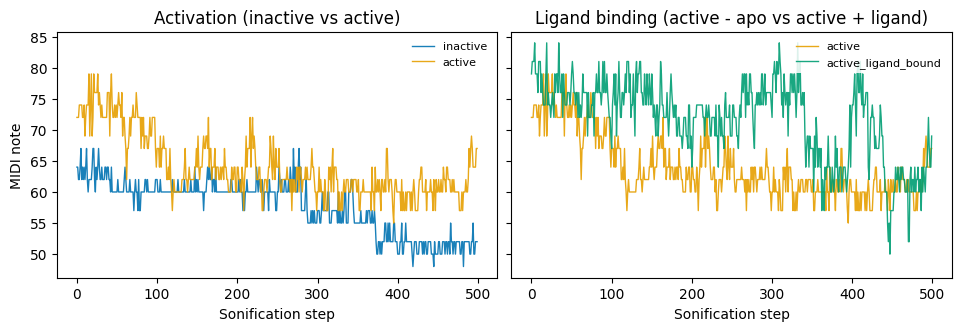

Saved: diag_midi_note_sequence_per_pair.png


In [ ]:
STATE_COLORS = {
    'inactive':            '#0072B2',
    'active':              '#E69F00',
    'active_ligand_bound': '#009E73',
}

# constrained_layout prevents the per-axis legend / title from being
# clipped or overlapping the shared-y axis labels.
fig, axes = plt.subplots(1, len(PAIRS), figsize=(9.5, 3.2),
                         sharey=True, constrained_layout=True)
if len(PAIRS) == 1:
    axes = [axes]
for ax, (pair_name, pair_cfg) in zip(axes, PAIRS.items()):
    for state in pair_cfg['states']:
        if state in mapping_tables:
            t = mapping_tables[state]
            ax.plot(t.index, t['midi_note'],
                    color=STATE_COLORS.get(state, 'k'),
                    linewidth=1.0, alpha=0.9, label=state)
    ax.set_title(pair_cfg['label'])
    ax.set_xlabel('Sonification step')
    # Legend with a semi-opaque background so it never hides the lines
    # behind it, and a fixed top-right anchor (loc='best' was picking
    # locations that crossed the data).
    ax.legend(loc='upper right', fontsize=8, frameon=True,
              framealpha=0.85, edgecolor='none')
axes[0].set_ylabel('MIDI note')
out = FIG_DIR / 'diag_midi_note_sequence_per_pair.png'
plt.savefig(out, dpi=200)
plt.show()
print('Saved:', out.name)
